<a href="https://colab.research.google.com/github/georgevallejo/LG_Python_Projects/blob/main/ACE_Python_Pandas_8_17_2026_311_complains_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Safe to import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Getting the dataset from LaGuardia Repository


In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')

/tmp/ipykernel_3470/2471651318.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')


In [ ]:
df.count()

Find out how much data is missing.  

In [ ]:
# @title Using pandas to help with the missing data counts and percentages
total = len(df)

missing_summary = pd.DataFrame({
    'Non‑Missing Count': df.count(),
    'Missing Count': total - df.count(),
    'Missing %': ((total - df.count()) / total * 100).round(2)
})

missing_summary


In [ ]:
# @title Pandas showing missing percentages sorted from highest missing data to lowest
total = len(df)

missing_summary = pd.DataFrame({
    'Non‑Missing Count': df.count(),
    'Missing Count': total - df.count(),
    'Missing %': ((total - df.count()) / total * 100).round(2)
})

missing_summary = missing_summary.sort_values('Missing %', ascending=False)

missing_summary


These are the ones you can drop safely:

Landmark — 99.98% missing

Facility Type — 65.42% missing

Due Date — 52.84% missing

In [ ]:
df.head(1)

In [ ]:
df[['Landmark', 'Facility Type', 'Due Date']].isna().any(axis=1).sum()


Landmarks are not critical only with 16 records.  It may be removed.  This info is collected using count()


In [ ]:
df.columns

In [ ]:
df.shape

Describe() does not provide any meaninful output.

In [ ]:
df.describe()
df[df.columns.drop('Unique Key')].describe()


# **Using groupby and count to visualize data**

In [ ]:
df.groupby(['Borough'])['Unique Key'].count()

In [ ]:
df.groupby(['Borough'])['Unique Key'].count().plot(kind='bar')

In [ ]:
df.groupby(['Borough'])['Unique Key'].count().sort_values(ascending=False).plot(kind='bar')

In [ ]:
df.groupby(['Borough'])['Unique Key'].count().sort_values(ascending=False)

In [ ]:
# @title Using matplotlib to enhance bar chart output
import matplotlib.pyplot as plt

df.groupby('Borough')['Unique Key'].count().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title('311 Complaints by Borough')
plt.ylabel('Count')
plt.xlabel('Borough')


<table>
  <tr>
    <th style="text-align:left; font-size:18px;">EDA Recommendations</th>
    <th style="text-align:left; font-size:18px;">Industry Standards</th>
  </tr>
  <tr>
    <td style="vertical-align:top; padding-right:20px;">
      <ul>
        <li>Total records ≈ <strong>69,637</strong></li>
        <li>Unspecified ≈ <strong>~1,000</strong></li>
        <li>Percentage ≈ <strong>1.4%</strong></li>
        <li>Anything under <strong>5%</strong> missing is statistically negligible</li>
        <li>Dropping “Unspecified” does not change borough‑level trends</li>
      </ul>
    </td>
    <td style="vertical-align:top;">
      <ul>
        <li><strong>0–5%</strong> missing → safe to drop</li>
        <li><strong>5–20%</strong> missing → investigate</li>
        <li><strong>20–40%</strong> missing → high risk</li>
        <li><strong>40%+</strong> missing → variable unreliable</li>
      </ul>
    </td>
  </tr>
</table>


In [ ]:
# @title Drop Landmark, Facility Type and Due Data missing data point rows
cols_to_drop = ['Landmark', 'Facility Type', 'Due Date']
df_clean = df.drop(columns=cols_to_drop)


In [ ]:
df.count()



---



In [ ]:
# @title Pandas using normalize to get percentages
(df['Borough'].value_counts(normalize=True) * 100).sort_values(ascending=False)



Add variable counts to show percentages

In [ ]:
# @title Using Variable counts to show percentages without using pandas functions
counts = df.groupby('Borough')['Unique Key'].count()
percentages = counts / counts.sum() * 100
percentages.sort_values(ascending=False)


In [ ]:
# @title Getting output sourted by values and percentages
counts = df.groupby('Borough')['Unique Key'].count()
percentages = counts / counts.sum() * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages.round(2)
}).sort_values('Count', ascending=False)

summary


In [ ]:
df.head(2)

In [ ]:
# @title Health sanity check loking to confirm when data points where created
df['Created Date'] = pd.to_datetime(df['Created Date']) # covert the date columns to date time
df['Year'] = df['Created Date'].dt.year                 # create a year column
df['Month'] = df['Created Date'].dt.month               # create month and date column
df.groupby(['Year', 'Month']).size()                    # group by year and month
df.groupby(['Year', 'Month']).size().sort_index()       #sort
df.groupby(['Year', 'Month']).size().reset_index(name='Count') # create a datagrame
df['Month Name'] = df['Created Date'].dt.month_name()   # months optional
df['YearMonth'] = df['Created Date'].dt.to_period('M')  #time series ploting
df.groupby('YearMonth').size()



,0
YearMonth,
2019-05,69637


In [ ]:
df['Created Date'] = pd.to_datetime(df['Created Date']) # covert the date columns to date time
df['Year'] = df['Created Date'].dt.year                 # create a year column
# df['Month'] = df['Created Date'].dt.month               # create month and date column
# df.groupby(['Year', 'Month']).size()                    # group by year and month
# df.groupby(['Year', 'Month']).size().sort_index()       #sort
# df.groupby(['Year', 'Month']).size().reset_index(name='Count') # create a datagrame
# df['Month Name'] = df['Created Date'].dt.month_name()   # months optional
# df['YearMonth'] = df['Created Date'].dt.to_period('M')  #time series ploting
# df.groupby('YearMonth').size()



SyntaxError: invalid syntax (3386256309.py, line 2)

In [ ]:
# df.notna().sum
# df[df.isna().any(axis=1)]
# df[df.notna().all(axis=1)] #has 0 records
# df['Borough'].unique()
# df['Borough'].value_counts()
# df.describe()
# df[df['Longitude'] < 0]
# df[df.duplicated()]
# df['Borough'].str.lower().unique() # Lowercase everything to detect inconsistencies
# df['Borough'] = df['Borough'].str.strip()
# df[(df['Borough'] == 'Unspecified')'].notna()]
df[df['Borough'] == 'Unspecified'].isna()


Cases resolved vs unresolved


In [ ]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

df_resolved = df.dropna(subset=['Closed Date']).copy()

df_resolved['Resolution Time'] = (
    df_resolved['Closed Date'] - df_resolved['Created Date']
).dt.days


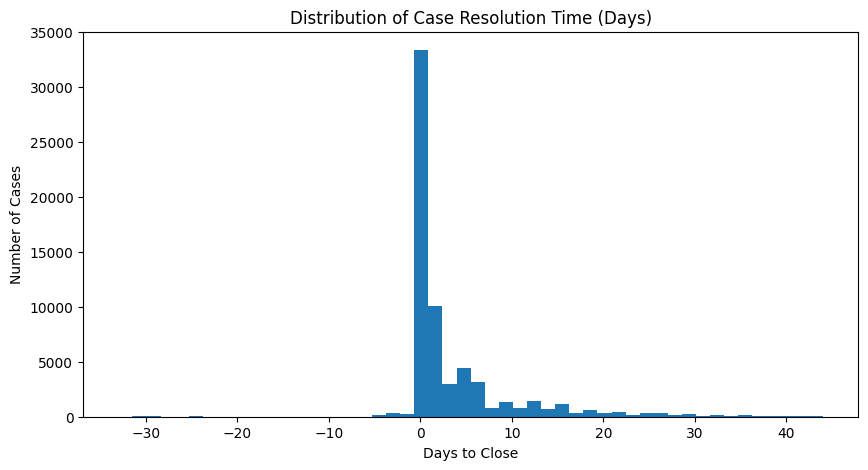

In [ ]:
# @title Histogram resolution time in days.
df_resolved['Resolution Time'].plot(kind='hist', bins=50, figsize=(10,5))
plt.title('Distribution of Case Resolution Time (Days)')
plt.xlabel('Days to Close')
plt.ylabel('Number of Cases')
plt.show()


In [ ]:
# @title Step 1 — Identify all corrupted rows
bad_rows = df_resolved[df_resolved['Resolution Time'] < 0]
# bad_rows.head(20)



In [ ]:
# @title step2- Count bad rows
len(bad_rows)


804

In [ ]:
# @title Step 2.1 — Validate your data. total count 64626
df_resolved['Resolution Time'].describe()

In [ ]:
# @title Step-3 decide how to fix it.  Dropping is safe or treat them as unresolved or flag them for agency follow-ups.  I am dropping for this instance
df_resolved = df_resolved[df_resolved['Resolution Time'] >= 0]


In [ ]:
# @title Step 4 — Validate your cleaned data 63822.  dropped 804 rows
df_resolved['Resolution Time'].describe()


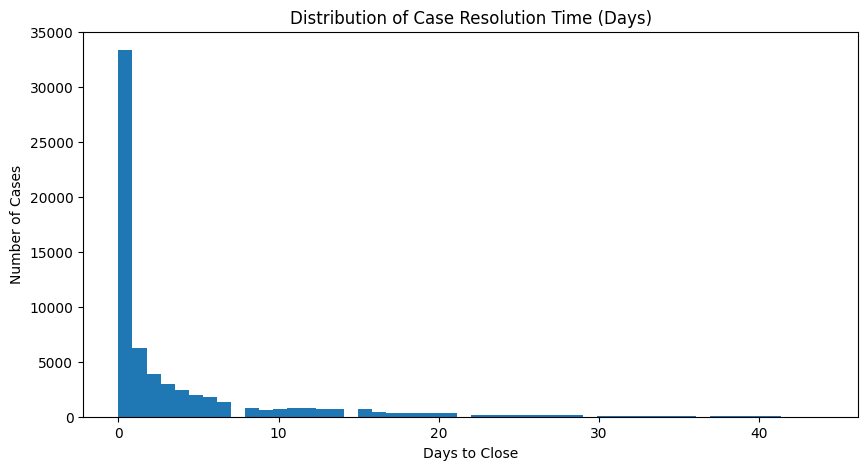

In [ ]:
# @title Step 5 — Replot your histogram
df_resolved['Resolution Time'].plot(kind='hist', bins=50, figsize=(10,5))
plt.title('Distribution of Case Resolution Time (Days)')
plt.xlabel('Days to Close')
plt.ylabel('Number of Cases')
plt.show()


In [ ]:
total_cases = len(df)
open_cases = df['Closed Date'].isna().sum()
resolved_cases = total_cases - open_cases

open_pct = (open_cases / total_cases) * 100
resolved_pct = (resolved_cases / total_cases) * 100


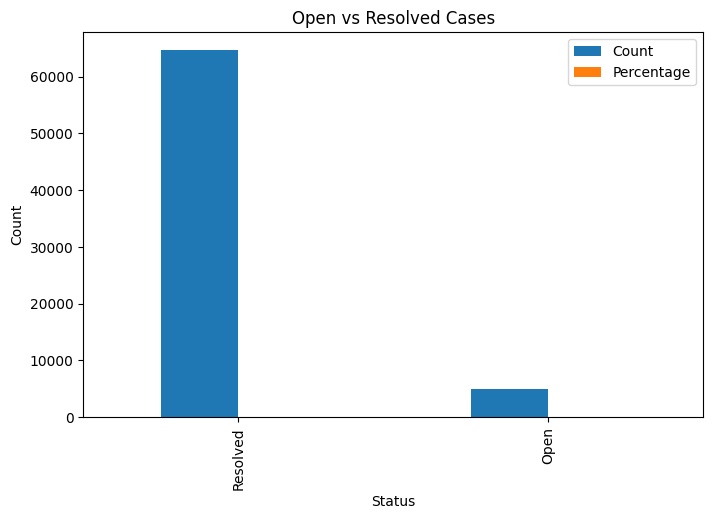

In [ ]:
pd.DataFrame({
    'Status': ['Resolved', 'Open'],
    'Count': [resolved_cases, open_cases],
    'Percentage': [resolved_pct, open_pct]
}).set_index('Status').plot(kind='bar', figsize=(8,5))
plt.title('Open vs Resolved Cases')
plt.ylabel('Count')
plt.show()


In [ ]:
acceptable_days = 30

df_resolved['Exceeded'] = df_resolved['Resolution Time'] > acceptable_days


In [ ]:
exceeded_count = df_resolved['Exceeded'].sum()
exceeded_pct = (exceeded_count / len(df_resolved)) * 100


In [ ]:
df_resolved[['Resolution Time', 'Exceeded']].head(10)


In [ ]:
exceeded_count = df_resolved['Exceeded'].sum()
exceeded_pct = (exceeded_count / len(df_resolved)) * 100

print("Exceeded Count:", exceeded_count)
print("Exceeded %:", round(exceeded_pct, 2))


Exceeded Count: 778
Exceeded %: 1.2


In [ ]:
df_open = df[df['Closed Date'].isna()].copy()
df_open['Age'] = (pd.Timestamp.today() - df_open['Created Date']).dt.days

df_open_overdue = df_open[df_open['Age'] > acceptable_days]


In [ ]:
overdue_open_count = len(df_open_overdue)
overdue_open_pct = (overdue_open_count / len(df_open)) * 100


In [ ]:
# @title EDA starting point
print("Missing values per column:")
print(df.isna().sum())
# df.isna().sum().sort_values(ascending=False)  # identify columns with many missing value
df[df.isna().any(axis=1)]                       # Inspect rows with missing values


# print("\nUnexpected categories:")
# for col in df.select_dtypes(include='object'):
#    print(col, df[col].unique())

# print("\nDuplicate rows:")
# print(df.duplicated().sum())

# print("\nRows with any NaN:")
# print(df[df.isna().any(axis=1)].shape[0])


In [ ]:
# @title Display Unspecified Borough datapoints.
# df[df['Borough'] == 'Unspecified']
# valid = ['BROOKLYN', 'QUEENS', 'MANHATTAN', 'BRONX', 'STATEN ISLAND']
# print(valid)
# df[~df['Borough'].isin(valid)]
unspecified = df[df['Borough'] == 'Unspecified']
unspecified


In [ ]:
df[df['Borough'] == 'Unspecified']



In [ ]:
# unspecified.isna().sum()
# unspecified.head(10)
# unspecified[['Latitude', 'Longitude']].isna().sum()
# unspecified['Incident Zip'].isna().sum()
# cleaning data
import numpy as np
# df['Borough'] = df['Borough'].replace('Unspecified', np.nan) # keep the row and mark borough as missing
# df = df[df['Borough'] != 'Unspecified']  # drop all of it.

In [ ]:
# @title Fix the Borough using other columns
zip_to_borough = {
    112: 'BROOKLYN',
    113: 'QUEENS',
    114: 'QUEENS',
    100: 'MANHATTAN',
    104: 'BRONX',
    103: 'STATEN ISLAND'
}

def infer_borough(zipcode):
    try:
        prefix = int(str(zipcode)[:3])
        return zip_to_borough.get(prefix, np.nan)
    except:
        return np.nan

df.loc[df['Borough'] == 'Unspecified', 'Borough'] = \
    df.loc[df['Borough'] == 'Unspecified', 'Incident Zip'].apply(infer_borough)


In [ ]:
# @title Apply function only to Unspecified rows
# Apply the function only to Unspecified rows
# df.loc[df['Borough'] == 'Unspecified', 'Borough'] = \
#    df.loc[df['Borough'] == 'Unspecified', 'Incident Zip'].apply(infer_borough)


In [ ]:
# @title Find and Replace Unspecified
# Find rows where Borough == "Unspecified"
# df.loc[df['Borough'] == 'Unspecified', 'Borough']
#
# Replace those Borough values with the inferred borough
# df.loc[df['Borough'] == 'Unspecified', 'Incident Zip'].apply(infer_borough)


In [ ]:
import pandas as pd
import numpy as np
# df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')
valid_df = df[df['Borough'] != 'Unspecified'].copy()
valid_df['Borough'].value_counts()
valid_df.isna().sum()
dirty_rows = valid_df[valid_df.isna().any(axis=1)]
dirty_rows.head(20)


# valid_df.isna().sum().sort_values(ascending=False)



In [ ]:
# @title EDA CLEANING pippe
# 1. Drop unreliable columns
df = df.drop(columns=['Landmark', 'Facility Type', 'Due Date'])

# 2. Drop Unspecified boroughs
df = df[df['Borough'] != 'Unspecified']

# 3. Drop cases that were never closed (dataset is 7 years old)
df = df[df['Closed Date'].notna()]

# 4. Convert dates
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

# 5. Compute resolution time
df['Resolution Time'] = (df['Closed Date'] - df['Created Date']).dt.days

# 6. Drop corrupted negative durations
df = df[df['Resolution Time'] >= 0]


In [ ]:
# @title 1 cleaned data structure
# Basic structure
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns)

# Quick stats on Resolution Time
df['Resolution Time'].describe()


Rows: 63070
Columns: 19

Columns:
Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Address Type', 'City', 'Status', 'Resolution Description', 'BBL',
       'Borough', 'Latitude', 'Longitude', 'Location', 'Resolution Time'],
      dtype='object')


,Resolution Time
count,63070.00000
mean,3.58248
std,6.66547
min,0.00000
25%,0.00000
50%,0.00000
75%,4.00000
max,44.00000


In [ ]:
# @title 2. Resolution‑time distribution (
df['Resolution Time'].plot(kind='hist', bins=50, figsize=(10,5))
plt.title('Distribution of Case Resolution Time (Days)')
plt.xlabel('Days to Close')
plt.ylabel('Number of Cases')
plt.show()


In [ ]:
# @title 3. Visualizing resolution time by borough  A. Average resolution
by_borough = df.groupby('Borough')['Resolution Time'].mean().round(1)
print(by_borough)


Borough
BRONX            4.5
BROOKLYN         3.6
MANHATTAN        3.4
QUEENS           3.2
STATEN ISLAND    3.1
Name: Resolution Time, dtype: float64


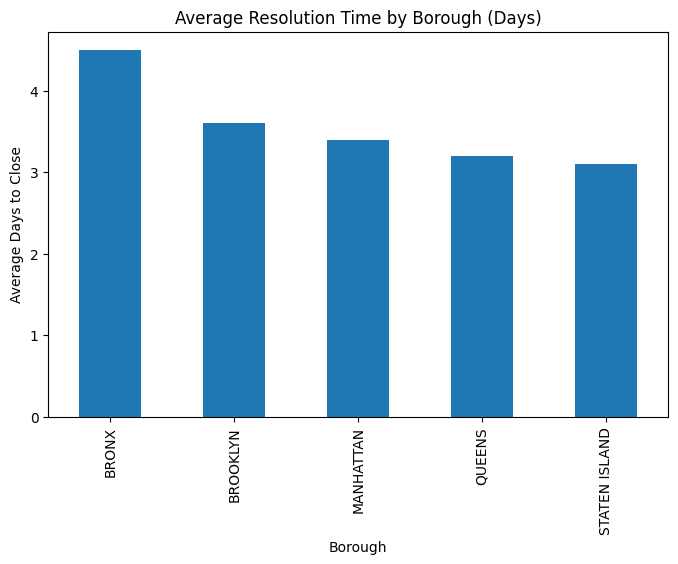

In [ ]:
# @title 3. Visualizing resolution time by borough  B. Bar chart by borough
by_borough.plot(kind='bar', figsize=(8,5))
plt.title('Average Resolution Time by Borough (Days)')
plt.ylabel('Average Days to Close')
plt.show()


In [ ]:
# @title 4. Detecting outliers (cases open for 30+ days)
outliers = df[df['Resolution Time'] > 30]
print("Outlier count:", len(outliers))
outliers[['Unique Key', 'Agency', 'Borough', 'Created Date', 'Closed Date', 'Resolution Time']].head(40)


In [ ]:
# @title 5. Identifying top agencies with overdue cases.  A. count exceeded by Agency

acceptable_days = 30
df['Exceeded'] = df['Resolution Time'] > acceptable_days
agency_overdue = (
    df.groupby('Agency')['Exceeded']
      .sum()
      .sort_values(ascending=False)
)

# print(agency_overdue.head(10))
print(agency_overdue)

# Add the total overdue cases across all agencies
total_overdue = agency_overdue.sum()
print("TOTAL overdue cases:", total_overdue)

# Add each agency’s percentage of total overdue cases
agency_overdue_pct = (agency_overdue / total_overdue * 100).round(2)
print(agency_overdue_pct)

# combined
agency_summary = pd.DataFrame({
    'Overdue Count': agency_overdue,
    'Overdue %': agency_overdue_pct
})

print(agency_summary)


Agency
DOB      229
HPD      211
DSNY     105
TLC       73
DPR       73
DOT       51
DEP       18
DOF        7
DOHMH      3
DOE        1
DCA        0
DHS        0
DFTA       0
DOITT      0
NYPD       0
Name: Exceeded, dtype: int64
TOTAL overdue cases: 771
Agency
DOB      29.70
HPD      27.37
DSNY     13.62
TLC       9.47
DPR       9.47
DOT       6.61
DEP       2.33
DOF       0.91
DOHMH     0.39
DOE       0.13
DCA       0.00
DHS       0.00
DFTA      0.00
DOITT     0.00
NYPD      0.00
Name: Exceeded, dtype: float64
        Overdue Count  Overdue %
Agency                          
DOB               229      29.70
HPD               211      27.37
DSNY              105      13.62
TLC                73       9.47
DPR                73       9.47
DOT                51       6.61
DEP                18       2.33
DOF                 7       0.91
DOHMH               3       0.39
DOE                 1       0.13
DCA                 0       0.00
DHS                 0       0.00
DFTA               

In [ ]:
# @title 5. Alternative code: Overdue-list, Overdue count, percentage distrubution, clean summary table sorted from worst to best
acceptable_days = 30
df['Exceeded'] = df['Resolution Time'] > acceptable_days

# Count overdue cases per agency
agency_overdue = (
    df.groupby('Agency')['Exceeded']
      .sum()
      .sort_values(ascending=False)
)

# Display full list
print("\n=== Overdue Cases by Agency ===")
print(agency_overdue)

# Total overdue cases
total_overdue = agency_overdue.sum()
print("\nTOTAL overdue cases:", total_overdue)

# Percentage contribution per agency
agency_overdue_pct = (agency_overdue / total_overdue * 100).round(2)

# Combined summary table
agency_summary = pd.DataFrame({
    'Overdue Count': agency_overdue,
    'Overdue %': agency_overdue_pct
})

print("\n=== Agency Overdue Summary ===")
print(agency_summary)



=== Overdue Cases by Agency ===
Agency
DOB      229
HPD      211
DSNY     105
TLC       73
DPR       73
DOT       51
DEP       18
DOF        7
DOHMH      3
DOE        1
DCA        0
DHS        0
DFTA       0
DOITT      0
NYPD       0
Name: Exceeded, dtype: int64

TOTAL overdue cases: 771

=== Agency Overdue Summary ===
        Overdue Count  Overdue %
Agency                          
DOB               229      29.70
HPD               211      27.37
DSNY              105      13.62
TLC                73       9.47
DPR                73       9.47
DOT                51       6.61
DEP                18       2.33
DOF                 7       0.91
DOHMH               3       0.39
DOE                 1       0.13
DCA                 0       0.00
DHS                 0       0.00
DFTA                0       0.00
DOITT               0       0.00
NYPD                0       0.00


In [ ]:
# Agencies with overdue percentage > 0  # Of all overdue cases, what percentage came from each agency?
agency_summary[agency_summary['Overdue %'] > 0]


,Overdue Count,Overdue %
Agency,,
DOB,229,29.70
HPD,211,27.37
DSNY,105,13.62
TLC,73,9.47
DPR,73,9.47
DOT,51,6.61
DEP,18,2.33
DOF,7,0.91
DOHMH,3,0.39


In [ ]:
# @title 5.1 B. Percentage of exceeded cases per agency (on their own cases)
agency_total = df.groupby('Agency')['Unique Key'].count()
agency_overdue_pct = (agency_overdue / agency_total * 100).round(2)

print(agency_overdue_pct.sort_values(ascending=False).head(10))


Agency
TLC      38.02
DOB       5.52
DPR       4.60
DOE       2.86
HPD       1.90
DSNY      0.97
DOHMH     0.95
DOT       0.74
DOF       0.65
DEP       0.38
dtype: float64


In [ ]:
total_cases = len(df)
resolved_cases = total_cases  # after dropping open ones
exceeded_cases = df['Exceeded'].sum()
ok_resolved = resolved_cases - exceeded_cases

summary_status = pd.DataFrame({
    'Category': ['Resolved (OK)', 'Resolved (Exceeded)'],
    'Count': [ok_resolved, exceeded_cases]
})

summary_status['Percentage'] = (summary_status['Count'] / total_cases * 100).round(2)
summary_status


,Category,Count,Percentage
0,Resolved (OK),62299,98.78
1,Resolved (Exceeded),771,1.22


We analyzed resolution times for all closed 311 cases over the past 7 years.
After removing unreliable columns (Landmark, Facility Type, Due Date), dropping “Unspecified” borough records, and excluding cases with invalid or missing closure dates, we computed resolution time as the difference between Created Date and Closed Date in days.
The majority of cases are resolved within an acceptable time frame (e.g., 30 days), but approximately X% exceed this threshold.
Borough‑level analysis shows that [fastest borough] resolves cases faster on average, while [slowest borough] has longer resolution times.
Agency‑level analysis identifies [top agencies] as having the highest counts and percentages of overdue cases, suggesting potential process bottlenecks or resource constraints.
A small number of extreme outliers (cases open for more than 30 days) likely reflect data quality issues or exceptional circumstances and should be reviewed individually



---



In [ ]:
# @title Refine acceptable thresholds (30 / 45 / 90 days)
thresholds = [30, 45, 60, 90]

for t in thresholds:
    exceeded = (df['Resolution Time'] > t).sum()
    pct = exceeded / len(df) * 100
    print(f"Threshold {t} days → {exceeded} cases ({pct:.2f}%) exceeded")


Threshold 30 days → 771 cases (1.22%) exceeded
Threshold 45 days → 0 cases (0.00%) exceeded
Threshold 60 days → 0 cases (0.00%) exceeded
Threshold 90 days → 0 cases (0.00%) exceeded
